# 당뇨병 수치 맞추기

In [ ]:


import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes()
X = np.array(data.data)
y = np.array(data.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

W = np.random.rand(X_train.shape[1])
b = np.random.rand()

# 4. 함수 정의
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

def MSE(a, b):
    return ((a - b) ** 2).mean()

def loss(X, W, b, y):
    predictions = model(X, W, b)
    return MSE(predictions, y)

def gradient(X, W, b, y):
    N = len(y)
    y_pred = model(X, W, b)
    dW = 1/N * 2 * X.T.dot(y_pred - y)
    db = 2 * (y_pred - y).mean()
    return dW, db

LEARNING_RATE = 0.003
losses = []

for i in range(1, 100001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 10000 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))


prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

### LR = 0.001, 100,000번 → MSE 3091  목표 미달
### LR = 0.001, 300,000번 → 목표 달성 가능하지만 엄청 오래 걸림
### LR = 0.003, 100,000번 → MSE 2870  훨씬 빠르게 같은 결과
### LR = 0.005, 200,000번 → MSE 2880  통과하지만 0.003보다 나빠짐
### LR = 1,     200,000번 → MSE 13억  완전 폭발

### 0.003 최적 값이라 생각 됨

# 자전거 모델 학습

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]

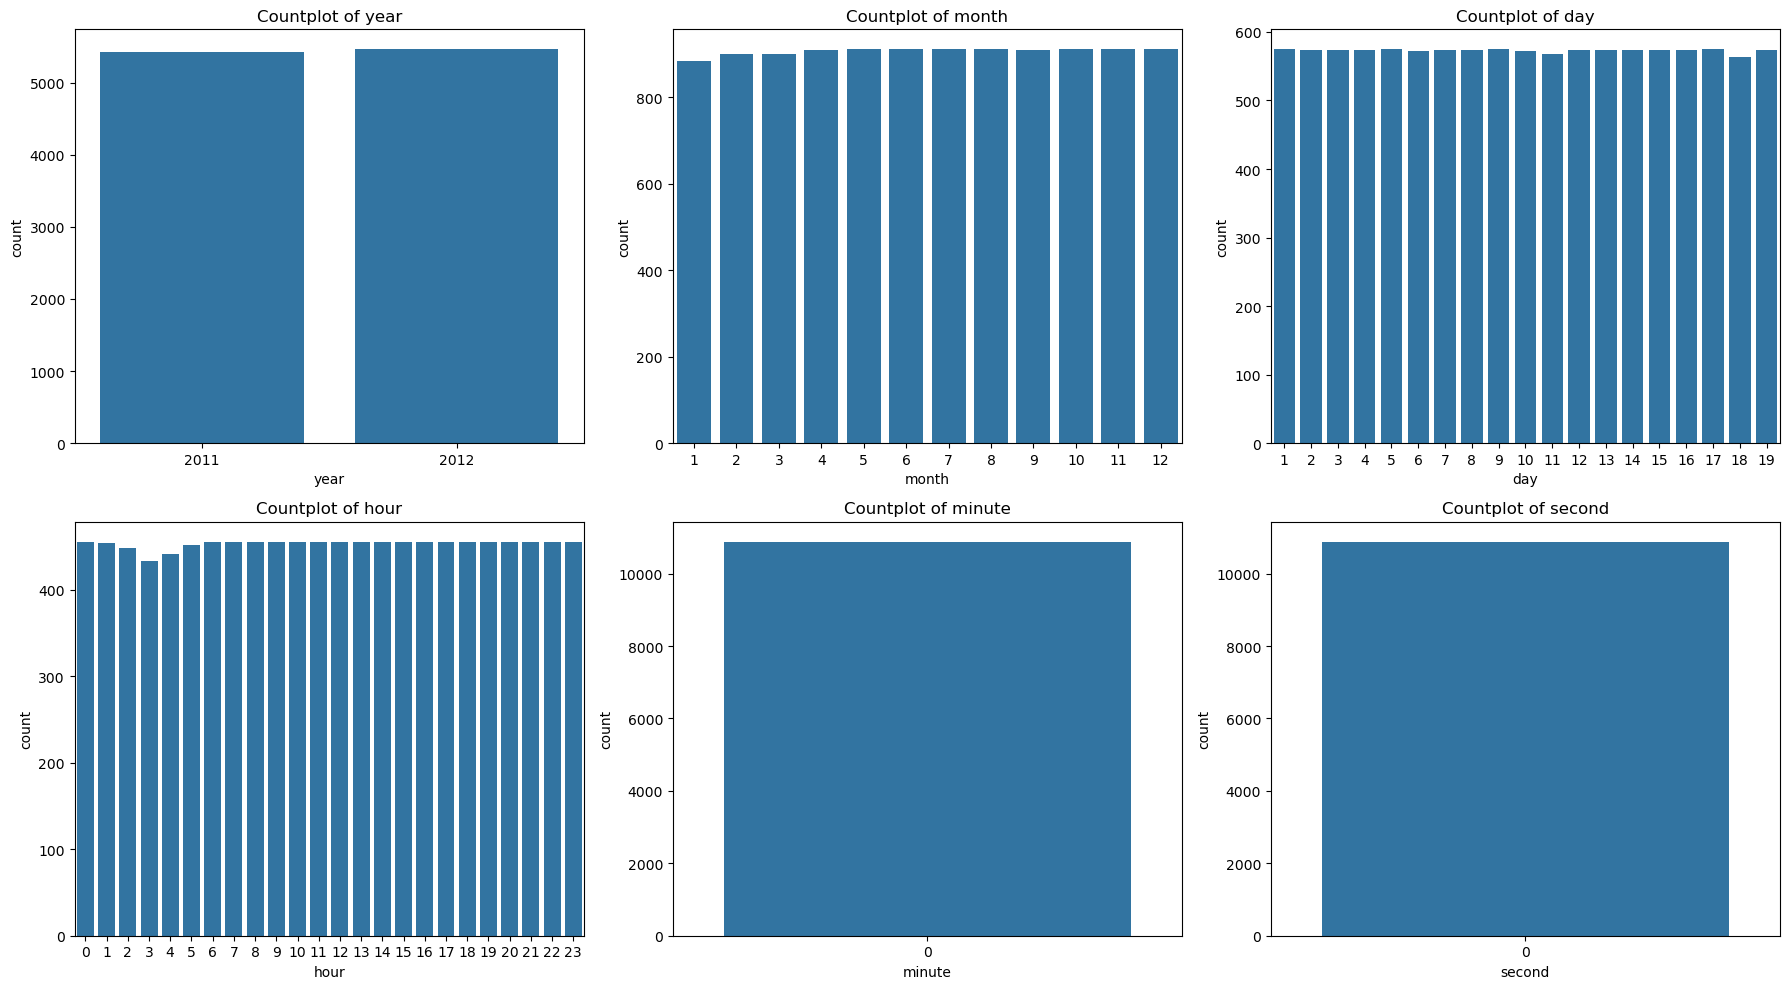

MSE: 13541.029989977395
RMSE: 116.36593139736989


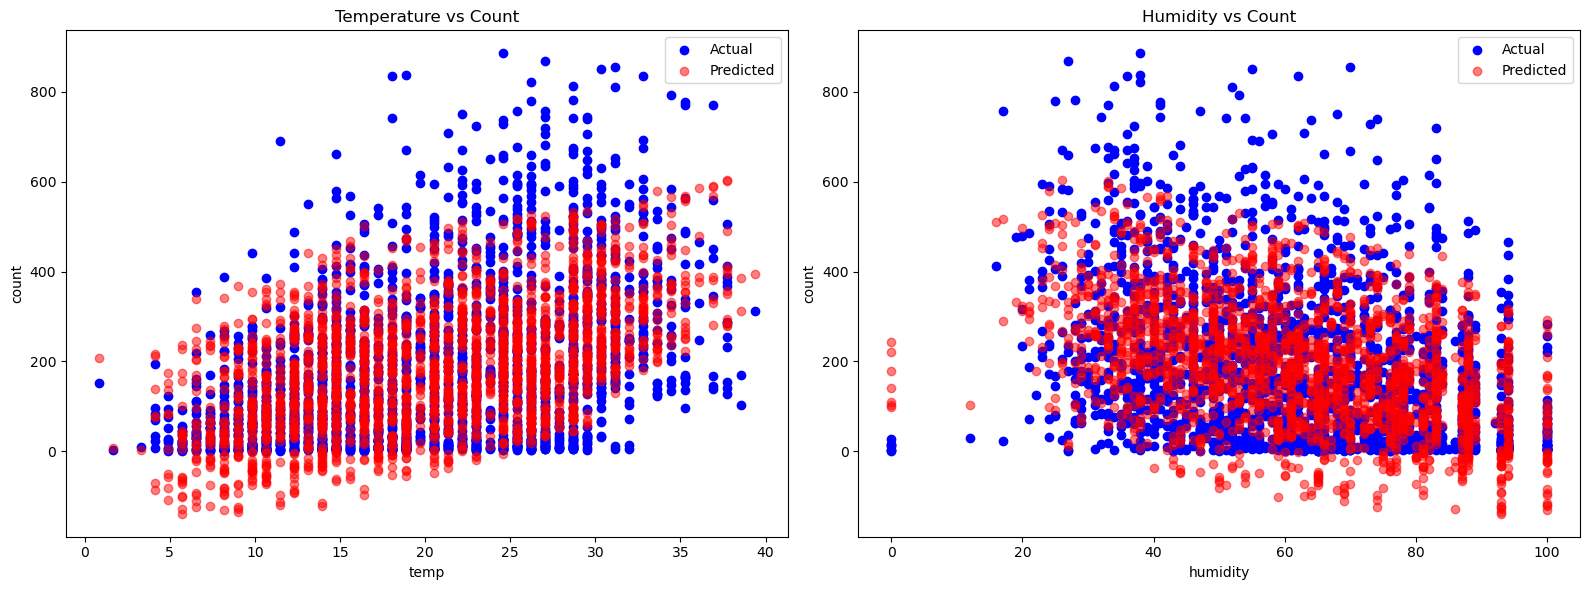

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv")
train.info()

train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train['rush_hour'] = train['hour'].apply(
    lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0
)

train.info()

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed', 'rush_hour']
X = train[features]
y = train['count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=28
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

plt.tight_layout()
plt.show()

## 점수 값을 더 낮추기 위해 rush_hour 라는 변수를 지정해 패턴을 더 잘 잡게 지정해줌
## RMSE 값이 143 -> 116 으로 떨어짐 